#Spam SMS Detection using Machine Learning

This project is developed as part of my Machine Learning Internship at CodSoft.
The goal of this project is to build a machine learning model that can classify SMS messages as Spam or Ham (Not Spam).

In this notebook, we will:

Load and explore the SMS dataset

Perform data preprocessing

Visualize the data using graphs

Convert text data into numerical features using TF-IDF

Train a machine learning model

Evaluate the model performance

The model helps automatically detect spam messages and can be useful in email and messaging filtering systems.

#Importing Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the Dataset

In [ ]:
sms_data = pd.read_csv('spam.csv', encoding='latin-1')

sms_data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


#Data Cleaning and Preparation

In [ ]:
sms_data = sms_data[['v1','v2']]
sms_data.columns = ['category','message']

sms_data.head()

,category,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Dataset Distribution Analysis

In [ ]:
sms_data['category'].value_counts()

,count
category,
ham,4825
spam,747


**Spam vs Ham Message Visualization**

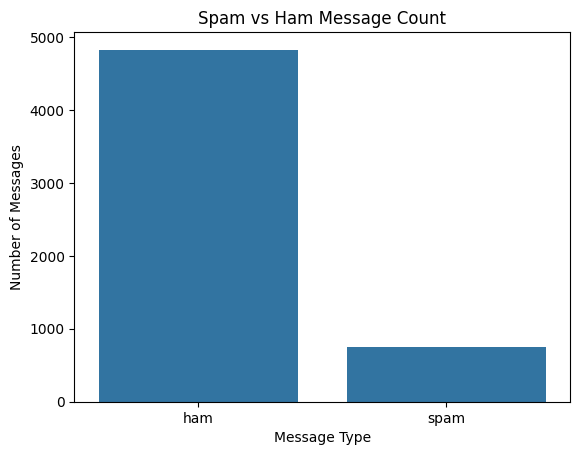

In [ ]:
sns.countplot(x='category', data=sms_data)
plt.title("Spam vs Ham Message Count")
plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

**Spam vs Ham Distribution (Pie Chart)**

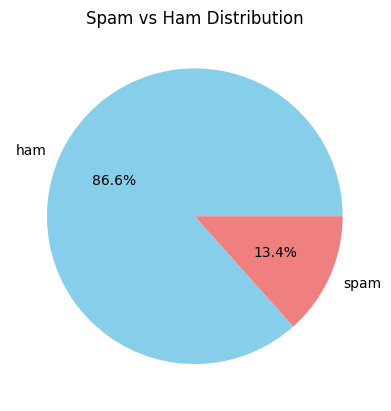

In [ ]:
sms_data['category'].value_counts().plot.pie(
autopct='%1.1f%%',
colors=['skyblue','lightcoral']
)
plt.title("Spam vs Ham Distribution")
plt.ylabel("")
plt.show()

**Message Length Analysis**

In [ ]:
sms_data['message_length'] = sms_data['message'].apply(len)

sms_data.head()

,category,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


**Spam vs Ham Message Length Comparison**


/tmp/ipykernel_702/2689138024.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='message_length', data=sms_data, palette='Set2')


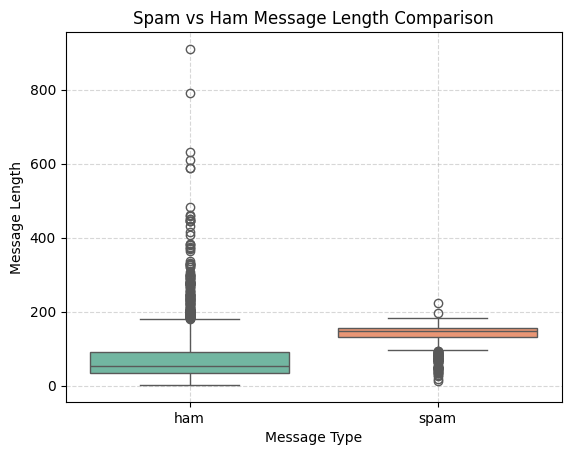

In [ ]:
sns.boxplot(x='category', y='message_length', data=sms_data, palette='Set2')
plt.title("Spam vs Ham Message Length Comparison")
plt.xlabel("Message Type")
plt.ylabel("Message Length")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Data Preprocessing**

**Label Encoding :**
 In this step, the categorical labels ham and spam are converted into numerical values so that machine learning algorithms can process the data.


In [ ]:
sms_data['category'] = sms_data['category'].map({'ham':0, 'spam':1})

sms_data.head()

,category,message,message_length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


**Splitting the Dataset into Training and Testing Sets**

In [ ]:
from sklearn.model_selection import train_test_split

X = sms_data['message']
y = sms_data['category']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

**Feature Extraction using TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Model Training



In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

MultinomialNB()

**Model Prediction**

In [ ]:
y_pred = model.predict(X_test_tfidf)

#Model Evaluation




In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy: {:.2f}%".format(accuracy * 100))

Model Accuracy: 96.23%


**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[965   0]
 [ 42 108]]


**Confusion Matrix Heatmap**

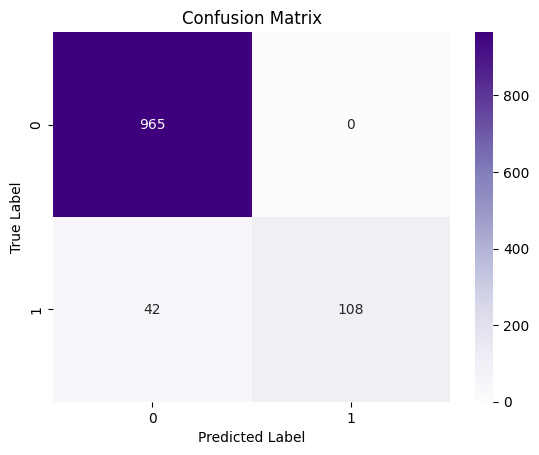

In [ ]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Testing the Model with New SMS Messages

In [ ]:
new_message = ["Congratulations! You have won a free prize. Claim now"]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

if prediction[0] == 1:
  print("Spam Message")
else:
  print("Ham Message")

Spam Message


In [ ]:
new_message = ["Win a brand new car! Participate now and claim your reward"]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

if prediction[0] == 1:
  print("Spam Message")
else:
  print("Ham Message")


Spam Message


In [ ]:
new_message = ["Hey, are you coming to college today?"]

new_message_tfidf = vectorizer.transform(new_message)

prediction = model.predict(new_message_tfidf)

if prediction[0] == 1:
  print("Spam Message")
else:
  print("Ham Message")

Ham Message


#Conclusion

In this project, I built a Spam SMS Detection model using Machine Learning.
The dataset was analyzed using different visualizations to understand message patterns.

The text data was converted into numerical features using TF-IDF and a Multinomial Naive Bayes classifier was used to train the model.

The model achieved an accuracy of 96%, showing that it can effectively distinguish between spam and legitimate messages.

This type of model can be used in messaging platforms and email systems to automatically filter unwanted messages.